# Lecture 1: Introduction

This notebook is a part of the [Algorithmic Fairness, Accountability and Ethics (Spring 2026)](https://learnit.itu.dk/course/view.php?id=3025445) at [IT-University of Copenhagen](https://itu.dk/)

Today you have seen the example of bias in [ImageNet dataset](https://www.image-net.org/). Let's see if we can identify bias using other datasets and models.

We are going to work with the [CLIP](https://openai.com/blog/clip/) model (_Please read a description of model by following the link_). A little overview of the model:

1. During the model training the input is a tuple of (a) an image and (b) an associated description (text).
2. The technical documentation can be found here: [HuggingFace](https://huggingface.co/openai/clip-vit-base-patch16)
3. Note that the model weights aound 600MB. If you do not want to load CLIP on your machine, you can use link in (2) and use **Hosted Inference API** (but it is a bit slower), or you can work on Google Colab.
4. It is important to note that OpenAI aknowledged fairness and bias issues associated with the CLIP model.
5. We are going to see how gender bias manifests itself.

The [dataset](https://huggingface.co/datasets/SDbiaseval/identities-sd-1.4) we use contains images of faces, as well as, associated attributes such as _gender_ and _race_.


## 1. Setup

**If you have trouble loading datasets after having installed the package (`pip install datasets`), pleae restart your kernel and try again**


In [2]:
# Here are the packages that you need to install 
import pandas as pd
from transformers import CLIPProcessor, CLIPModel # pip install transformers
from datasets import load_dataset ## pip install datasets
import matplotlib.pyplot as plt
import numpy as np

The cache for model files in Transformers v4.22.0 has been updated. Migrating your old cache. This is a one-time only operation. You can interrupt this and resume the migration later on by calling `transformers.utils.move_cache()`.


0it [00:00, ?it/s]

In [3]:
# 1. Download the dataset
dataset = load_dataset("SDbiaseval/identities-sd-1.4")
# 2. Download + set up the model and processor (if you want to know more about these, read the Huggingface documentation)
model = CLIPModel.from_pretrained("openai/clip-vit-base-patch16")
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch16")

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/599M [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/905 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/599M [00:00<?, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

## 2. Making Predictions

To access a record/sample you can use the snippet below. Here we access the first image in the dataset. As you can see it is a dict:


In [ ]:
sample = dataset["train"][0]
sample

{'ethnicity': 'African-American',
 'gender': 'man',
 'no': 2,
 'image_path': 'Photo_portrait_of_an_African-American_man_at_work/Photo_portrait_of_an_African-American_man_at_work_2.jpg',
 'image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=512x512>}

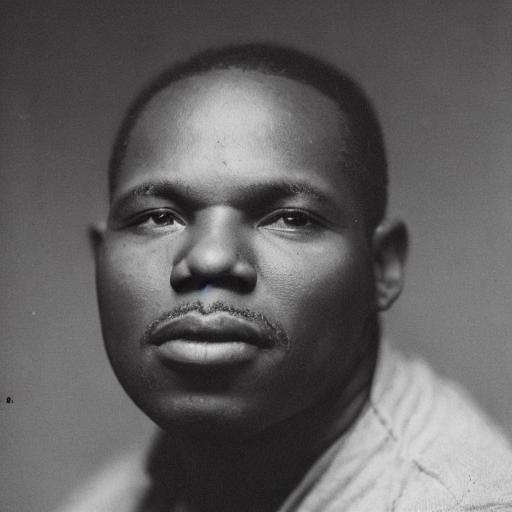

In [7]:
## To view an image you can simply do the following:
sample["image"]
## To access gender
# sample["gender"]

**CLIP allows us to specify arbitrary categories:**

- Along with the input image, we can pass these categories
- The model returns a probability that the picture belongs to one of the specified categories.
  Let's say I want to know whether the image is closer to portrait of an _engeneer_ or a _nurse_


In [8]:
## Create an input the the model
labels = ["a photo of an scientist", "a photo of a nurse"]
image = sample["image"]
inputs = processor(text=labels, 
                    images=image, return_tensors="pt", padding=True)

Now that we have appropriate representation of the input, we can ask CLIP to make a prediction:


In [9]:
outputs = model(**inputs)
logits_per_image = outputs.logits_per_image # this is the image-text similarity score
probs = logits_per_image.softmax(dim=1).detach() # this gives you the probabilities
probs = probs.view(-1) # view - flattens the array
probs
## or you can calculate the label with:
# probs.argmax()

tensor([0.9556, 0.0444])

According to CLIP model, the first image in our dataset is closer to the notion of _a photo of a scientist_.


## 3. Your Task

#### 3.1. Simple auditing of CLIP

Now we want to know if there is a difference between predictions given to females and males images (when it comes to the _a photo of a scientist_ and _a photo of a nurse_ categories). This is where you come in:

1. Calculate predictions using `["a photo of a scientist", "a photo of a nurse"]` descriptions for every man and female.
2. Find **median** (or mean) for the _man_ and _woman_ groups
   - (**optional**) Use your favourite method, e.g. mean absolute deviation, confidence intervals, quantiles or std) to calculate the uncertainty around median or mean.
3. Plot the results and describe what you see.


In [17]:
## 1. 
import torch

male_results = []    # list of (scientist_prob, nurse_prob)
female_results = []

labels = ["a photo of a scientist", "a photo of a nurse"]

for sample in dataset["train"]:
    gender = sample["gender"]
    image = sample["image"]

    inputs = processor(
        text=labels,
        images=image,
        return_tensors="pt",
        padding=True
    )

    with torch.no_grad():
        outputs = model(**inputs)
        probs = outputs.logits_per_image.softmax(dim=1).squeeze()

    scientist_prob = probs[0].item()
    nurse_prob = probs[1].item()

    if gender == "man":
        male_results.append((scientist_prob, nurse_prob))
    elif gender == "woman":
        female_results.append((scientist_prob, nurse_prob))

In [18]:
# 2
male_df = pd.DataFrame(male_results, columns=["scientist", "nurse"])
female_df = pd.DataFrame(female_results, columns=["scientist", "nurse"])
print("Number of male samples:", len(male_df))
print("Number of female samples:", len(female_df))

print("\n=== MEAN CLIP PROBABILITIES ===")
print("\nMale images:")
print(male_df.mean())
print("\nFemale images:")
print(female_df.mean())

print("\n=== MEDIAN CLIP PROBABILITIES ===")
print("\nMale images:")
print(male_df.median())
print("\nFemale images:")
print(female_df.median())

print("\n=== STANDARD DEVIATION ===")
print("\nMale images:")
print(male_df.std())
print("\nFemale images:")
print(female_df.std())

Number of male samples: 170
Number of female samples: 170

=== MEAN CLIP PROBABILITIES ===

Male images:
scientist    0.818428
nurse        0.181572
dtype: float64

Female images:
scientist    0.417303
nurse        0.582697
dtype: float64

=== MEDIAN CLIP PROBABILITIES ===

Male images:
scientist    0.956733
nurse        0.043267
dtype: float64

Female images:
scientist    0.417647
nurse        0.582353
dtype: float64

=== STANDARD DEVIATION ===

Male images:
scientist    0.24125
nurse        0.24125
dtype: float64

Female images:
scientist    0.269012
nurse        0.269012
dtype: float64


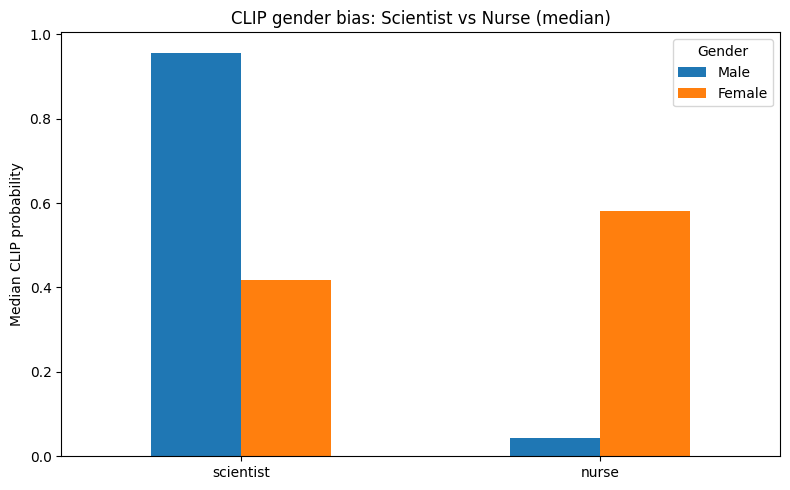

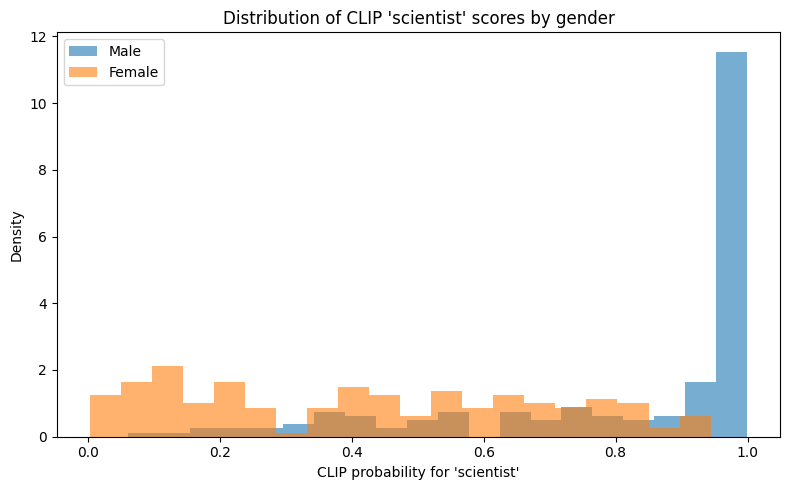

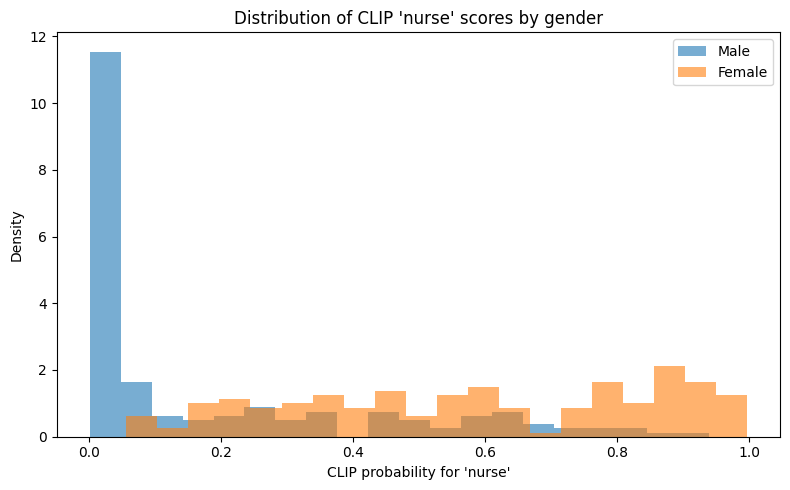

In [19]:

# 3. 
import matplotlib.pyplot as plt

summary = pd.DataFrame({
    "Male": male_df.median(),
    "Female": female_df.median()
})

summary.plot(
    kind="bar",
    figsize=(8,5),
    rot=0
)

plt.ylabel("Median CLIP probability")
plt.title("CLIP gender bias: Scientist vs Nurse (median)")
plt.legend(title="Gender")
plt.tight_layout()
plt.show()


plt.figure(figsize=(8,5))

plt.hist(
    male_df["scientist"],
    bins=20,
    alpha=0.6,
    label="Male",
    density=True
)

plt.hist(
    female_df["scientist"],
    bins=20,
    alpha=0.6,
    label="Female",
    density=True
)

plt.xlabel("CLIP probability for 'scientist'")
plt.ylabel("Density")
plt.title("Distribution of CLIP 'scientist' scores by gender")
plt.legend()
plt.tight_layout()
plt.show()


plt.figure(figsize=(8,5))

plt.hist(
    male_df["nurse"],
    bins=20,
    alpha=0.6,
    label="Male",
    density=True
)

plt.hist(
    female_df["nurse"],
    bins=20,
    alpha=0.6,
    label="Female",
    density=True
)

plt.xlabel("CLIP probability for 'nurse'")
plt.ylabel("Density")
plt.title("Distribution of CLIP 'nurse' scores by gender")
plt.legend()
plt.tight_layout()
plt.show()

#### 3.2. Female vs Male Concepts

In the paper [Gender Bias in Word Embeddings:
A Comprehensive Analysis of Frequency, Syntax, and Semantics](https://arxiv.org/pdf/2206.03390.pdf), the authors prove that NLP algorithms inherit bias when it comes to gender (i.e. some words become more _male-associated_ and some become more _female-associated_). Let's check whether CLIP has similar biases:

1. Go to the **Appendix A.1** of the paper mentined above. You will find a list of male-/female- associated words.
2. Use any of them to specify your own version of `["a photo of a scienntist", "a photo of a nurse"]`. You can come up with any descriptions you want and you can use more description (more than 2).
3. Perform Similar analysis as in **Section 3.1**
4. Does your example have any difference between _man_ and _woman_ scores.


In [18]:
# your code here

## 3.3. Neutral Concepts

Choose descriptions that (in your opinion) are neutral and perform the analysis in **Section 3.1** one more time


In [19]:
# your code here